# ❤️ Heart Disease Prediction using Machine Learning
### An End-to-End Supervised Machine Learning Pipeline
**Developed during:** PYML Internship at Anveshan Foundation, Indira Gandhi Delhi Technical University for Women (IGDTUW)

---

## 📌 Project Overview
Cardiovascular diseases (CVDs) are the leading cause of death globally. Early detection of heart disease through clinical and diagnostic features can significantly improve patient outcomes.

In this notebook, we implement an **end-to-end, leakage-safe machine learning workflow**:
1. **Exploratory Data Analysis (EDA):** Analyze distributions, correlations, and clinical features.
2. **Data Preprocessing & Encoding:** Construct a `ColumnTransformer` for numerical standardization and categorical encoding.
3. **Leakage-Safe Train/Test Split:** Stratified 80/20 split ($n=734$ train, $n=184$ test).
4. **SMOTE & 5-Fold Cross-Validation:** Oversampling minority classes strictly within training folds using `imblearn.pipeline.Pipeline`.
5. **Model Benchmarking:** Train and tune 6 classifiers (Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost).
6. **Model Evaluation:** Compare Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices on the held-out test set.
7. **Interpretability:** Extract gain-based feature importance from XGBoost.
8. **Artifact Serialization:** Save production pipeline for interactive Streamlit deployment.

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All dependencies imported successfully.")

All dependencies imported successfully.


---
## 1. 📂 Dataset Loading & Inspection

The dataset (`heart_final.csv`) contains **918 patient observations** aggregated from 5 benchmark cardiovascular cohorts (Cleveland, Hungarian, Switzerland, Long Beach VA, and Statlog).

In [2]:
# Resolve dataset path relative to notebooks directory or project root
data_path = os.path.join('..', 'data', 'heart_final.csv')
if not os.path.exists(data_path):
    data_path = 'data/heart_final.csv'

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

Dataset Shape: 918 rows, 12 columns



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Check data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
# Statistical summary of numerical features
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [5]:
print("Missing values per column:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


---
## 2. 📊 Exploratory Data Analysis (EDA)

We explore the distribution of the target variable (`HeartDisease`), categorical risk factors, and continuous clinical measurements.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\4239142055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Normal (0)', 'Heart Disease (1)'], y=target_counts.values, palette=['#38a169', '#e53e3e'])


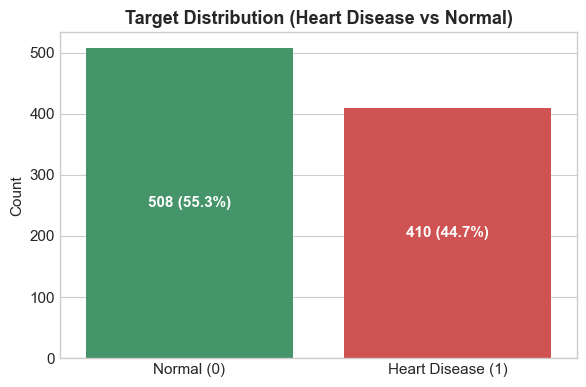

In [6]:
# Target variable distribution
plt.figure(figsize=(6, 4))
target_counts = df['HeartDisease'].value_counts()
ax = sns.barplot(x=['Normal (0)', 'Heart Disease (1)'], y=target_counts.values, palette=['#38a169', '#e53e3e'])
plt.title("Target Distribution (Heart Disease vs Normal)", fontsize=13, fontweight='bold')
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df):.1%})', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

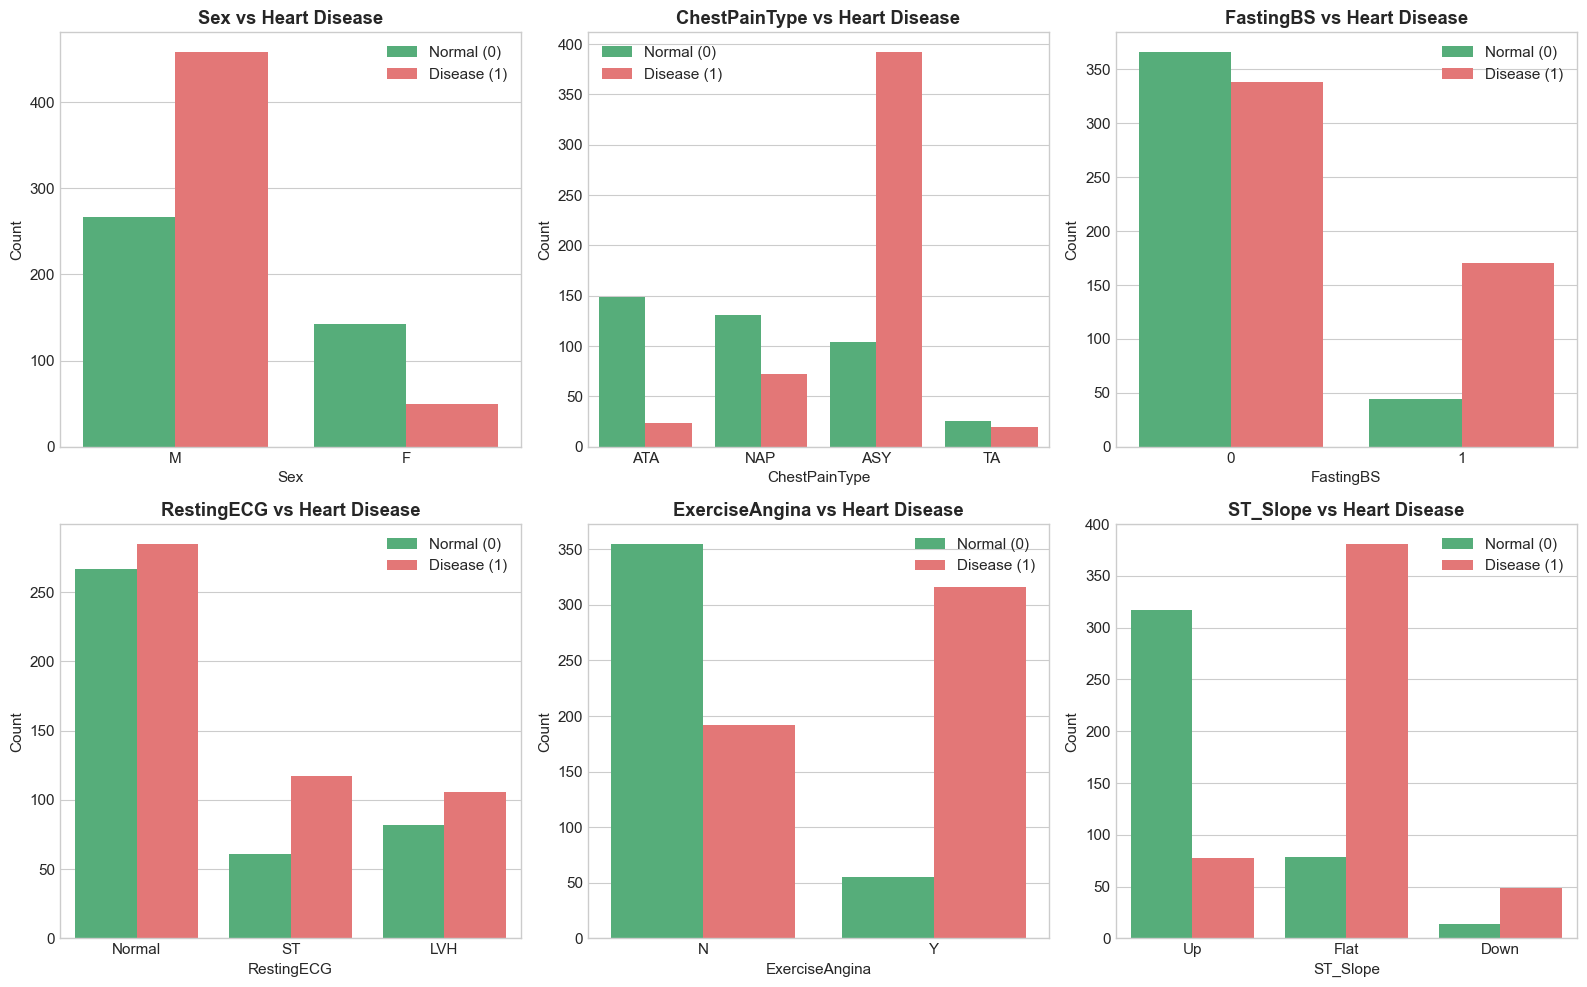

In [7]:
cat_cols_eda = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_eda):
    sns.countplot(data=df, x=col, hue='HeartDisease', palette=['#48bb78', '#f56565'], ax=axes[idx])
    axes[idx].set_title(f'{col} vs Heart Disease', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(['Normal (0)', 'Disease (1)'])

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx, 1].set_xticklabels(['Normal (0)', 'Disease (1)'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx, 1].set_xticklabels(['Normal (0)', 'Disease (1)'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_536\1734217892.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx, 1].set_xticklabels(['Normal (0)', 'Disease (1)'])


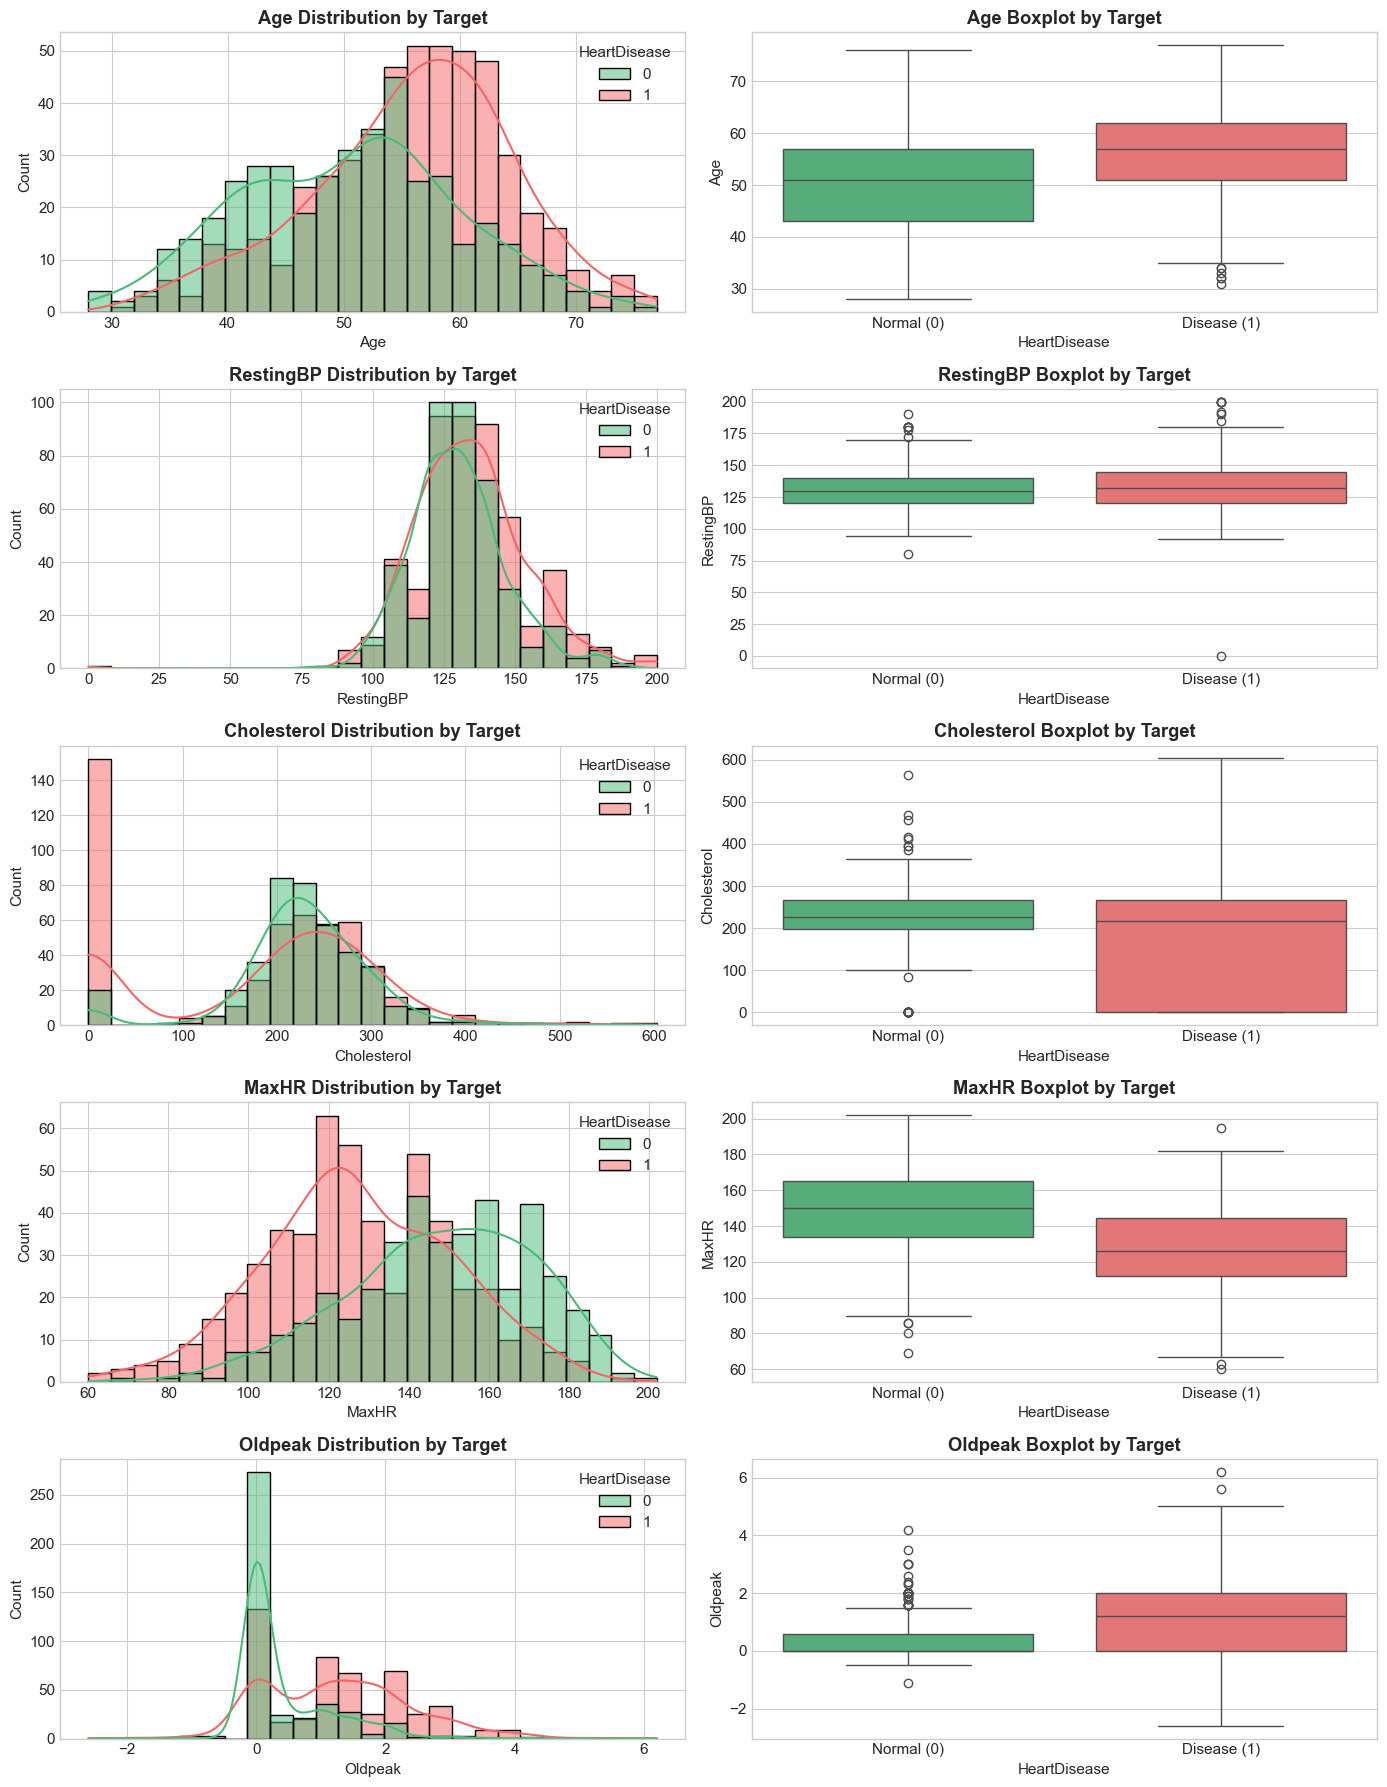

In [8]:
num_cols_eda = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(len(num_cols_eda), 2, figsize=(14, 18))

for idx, col in enumerate(num_cols_eda):
    # Histogram
    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True, bins=25, 
                 palette=['#48bb78', '#f56565'], ax=axes[idx, 0])
    axes[idx, 0].set_title(f'{col} Distribution by Target', fontweight='bold')
    
    # Boxplot
    sns.boxplot(data=df, x='HeartDisease', y=col, palette=['#48bb78', '#f56565'], ax=axes[idx, 1])
    axes[idx, 1].set_xticklabels(['Normal (0)', 'Disease (1)'])
    axes[idx, 1].set_title(f'{col} Boxplot by Target', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. ⚙️ Preprocessing & ColumnTransformer Architecture

### Feature Taxonomy:
- **5 Continuous Numerical Features:** `['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']` $	o$ Standardized using `StandardScaler()`.
- **6 Categorical / Binary Features:** `['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']` $	o$ Encoded using `OneHotEncoder(drop='first')`.
  - *Note:* `FastingBS` is a discrete binary indicator ($1$ if fasting sugar $> 120$ mg/dl, $0$ otherwise) and is handled cleanly via One-Hot Encoding.
- **Target:** `HeartDisease` ($1$ = Heart Disease, $0$ = Normal).

In [9]:
# Define features and target
NUMERICAL_COLS = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
CATEGORICAL_COLS = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
TARGET_COL = 'HeartDisease'

X = df[NUMERICAL_COLS + CATEGORICAL_COLS].copy()
y = df[TARGET_COL].astype(int).copy()

# Stratified 80/20 train/test split strictly before any preprocessing fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({y_train.sum()} positive, {len(y_train) - y_train.sum()} normal)")
print(f"Held-out test set: {X_test.shape[0]} samples ({y_test.sum()} positive, {len(y_test) - y_test.sum()} normal)")

Training set: 734 samples (406 positive, 328 normal)
Held-out test set: 184 samples (102 positive, 82 normal)


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLS),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_COLS)
    ],
    remainder='drop'
)

# Inspect transformed feature names
preprocessor.fit(X_train)
transformed_names = preprocessor.get_feature_names_out()
print(f"Total transformed features: {len(transformed_names)}")
print("Transformed column names:", transformed_names)

Total transformed features: 15
Transformed column names: ['num__Age' 'num__RestingBP' 'num__Cholesterol' 'num__MaxHR'
 'num__Oldpeak' 'cat__Sex_M' 'cat__ChestPainType_ATA'
 'cat__ChestPainType_NAP' 'cat__ChestPainType_TA' 'cat__FastingBS_1'
 'cat__RestingECG_Normal' 'cat__RestingECG_ST' 'cat__ExerciseAngina_Y'
 'cat__ST_Slope_Flat' 'cat__ST_Slope_Up']


---
## 4. 🤖 Leakage-Safe Model Training & Hyperparameter Tuning

To prevent data leakage, we assemble an `imblearn.pipeline.Pipeline`:

$$\text{ColumnTransformer} \longrightarrow \text{SMOTE (Train Folds Only)} \longrightarrow \text{Classifier}$$

The pipeline is passed directly into `RandomizedSearchCV(cv=5, scoring='accuracy', random_state=42)`, guaranteeing that preprocessing and oversampling are fit **strictly inside each cross-validation training fold**.

In [11]:
# Define hyperparameter search spaces for 6 classifiers
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs', 'liblinear']
        },
        "n_iter": 5
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            'classifier__n_neighbors': list(range(3, 20)),
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan']
        },
        "n_iter": 10
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf', 'poly'],
            'classifier__gamma': ['scale', 'auto']
        },
        "n_iter": 6
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__max_depth': [None] + list(range(3, 20)),
            'classifier__min_samples_split': [2, 5, 10, 15],
            'classifier__min_samples_leaf': [1, 2, 4, 6]
        },
        "n_iter": 20
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'classifier__n_estimators': [100, 200, 300, 400, 500],
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__bootstrap': [True, False]
        },
        "n_iter": 20
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='logloss', random_state=42),
        "params": {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7, 10],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'classifier__subsample': [0.6, 0.8, 1.0],
            'classifier__colsample_bytree': [0.6, 0.8, 1.0],
            'classifier__gamma': [0, 1, 5]
        },
        "n_iter": 20
    }
}

trained_pipelines = {}
test_results = {}

print("Training all 6 models with 5-fold cross-validation...")
for name, cfg in model_configs.items():
    # Construct leakage-safe pipeline
    pipe = ImbPipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), NUMERICAL_COLS),
                ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_COLS)
            ]
        )),
        ('smote', SMOTE(random_state=42)),
        ('classifier', cfg['model'])
    ])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg['params'],
        n_iter=cfg['n_iter'],
        cv=5,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    trained_pipelines[name] = best_pipe
    
    # Evaluate on untouched held-out test split
    y_pred = best_pipe.predict(X_test)
    y_prob = best_pipe.predict_proba(X_test)[:, 1] if hasattr(best_pipe, 'predict_proba') else None
    
    test_results[name] = {
        'Accuracy': float(accuracy_score(y_test, y_pred)),
        'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'F1-Score': float(f1_score(y_test, y_pred, zero_division=0)),
        'ROC-AUC': float(roc_auc_score(y_test, y_prob)) if y_prob is not None else 0.0,
        'Best_Params': {k.replace('classifier__', ''): v for k, v in search.best_params_.items()},
        'Confusion_Matrix': confusion_matrix(y_test, y_pred),
        'Classification_Report': classification_report(y_test, y_pred)
    }
    
    print(f"✓ {name:20s} | Test Acc: {test_results[name]['Accuracy']*100:.2f}% | Recall: {test_results[name]['Recall']*100:.2f}%")

Training all 6 models with 5-fold cross-validation...


✓ Logistic Regression  | Test Acc: 88.04% | Recall: 89.22%


✓ KNN                  | Test Acc: 89.13% | Recall: 90.20%


✓ SVM                  | Test Acc: 86.41% | Recall: 90.20%


✓ Decision Tree        | Test Acc: 84.24% | Recall: 83.33%


✓ Random Forest        | Test Acc: 86.96% | Recall: 91.18%


✓ XGBoost              | Test Acc: 89.13% | Recall: 91.18%


---
## 5. 📈 Comparative Model Evaluation & Visualizations

We evaluate all 6 classifiers on the untouched test split ($n=184$):

In [12]:
results_table = pd.DataFrame([
    {
        'Model': m_name,
        'Accuracy (%)': f"{res['Accuracy']*100:.2f}%",
        'Precision (%)': f"{res['Precision']*100:.2f}%",
        'Recall (%)': f"{res['Recall']*100:.2f}%",
        'F1-Score (%)': f"{res['F1-Score']*100:.2f}%",
        'ROC-AUC (%)': f"{res['ROC-AUC']*100:.2f}%"
    }
    for m_name, res in test_results.items()
])

display(results_table)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Logistic Regression,88.04%,89.22%,89.22%,89.22%,92.55%
1,KNN,89.13%,90.20%,90.20%,90.20%,94.52%
2,SVM,86.41%,85.98%,90.20%,88.04%,92.20%
3,Decision Tree,84.24%,87.63%,83.33%,85.43%,89.85%
4,Random Forest,86.96%,86.11%,91.18%,88.57%,93.03%
5,XGBoost,89.13%,89.42%,91.18%,90.29%,92.38%


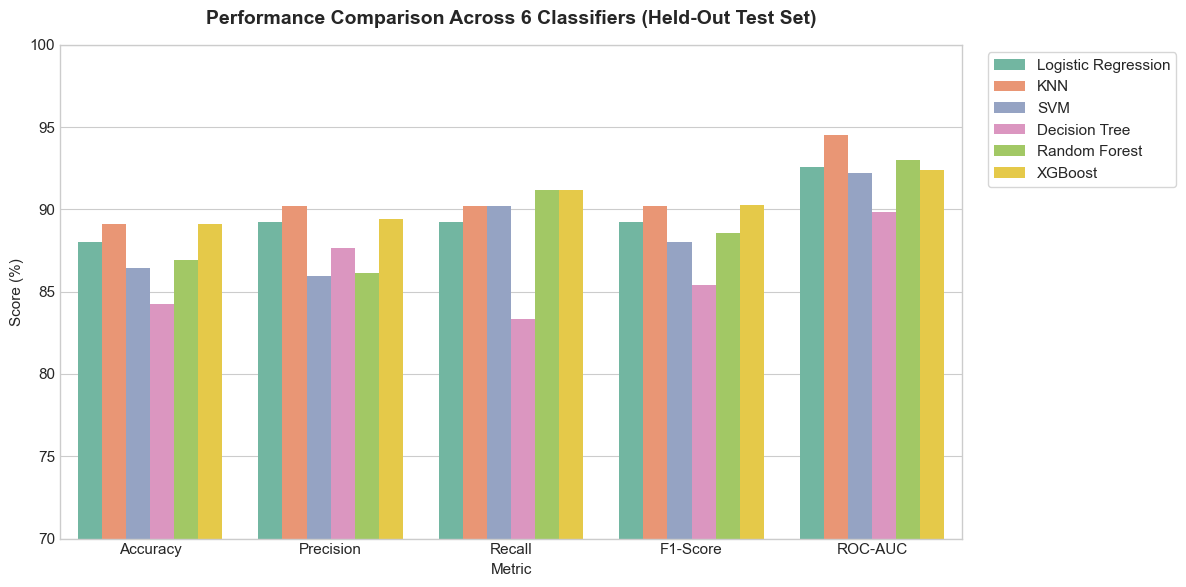

In [13]:
df_plot = pd.DataFrame([
    {
        'Model': m_name,
        'Accuracy': res['Accuracy'] * 100,
        'Precision': res['Precision'] * 100,
        'Recall': res['Recall'] * 100,
        'F1-Score': res['F1-Score'] * 100,
        'ROC-AUC': res['ROC-AUC'] * 100
    }
    for m_name, res in test_results.items()
])

df_melt = df_plot.melt(id_vars='Model', var_name='Metric', value_name='Score (%)')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Metric', y='Score (%)', hue='Model', palette='Set2')
plt.title('Performance Comparison Across 6 Classifiers (Held-Out Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.ylim(70, 100)
plt.ylabel('Score (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

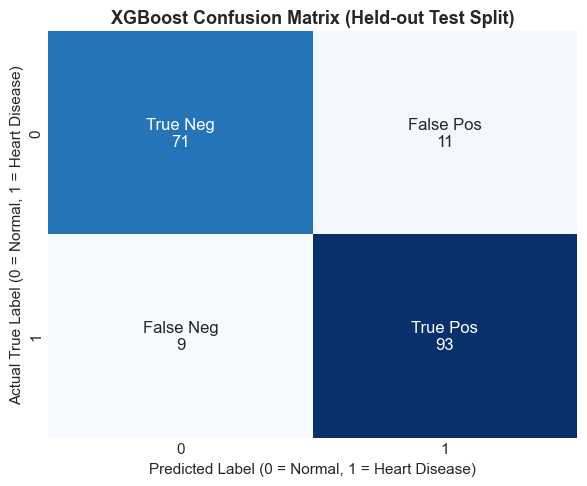


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [14]:
# Confusion Matrix for Selected XGBoost Model
best_xgb_pipe = trained_pipelines['XGBoost']
cm_xgb = test_results['XGBoost']['Confusion_Matrix']

plt.figure(figsize=(6, 5))
labels = [
    [f"True Neg\n{cm_xgb[0,0]}", f"False Pos\n{cm_xgb[0,1]}"],
    [f"False Neg\n{cm_xgb[1,0]}", f"True Pos\n{cm_xgb[1,1]}"]
]

sns.heatmap(cm_xgb, annot=np.array(labels), fmt="", cmap="Blues", cbar=False, annot_kws={"size": 12})
plt.title("XGBoost Confusion Matrix (Held-out Test Split)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label (0 = Normal, 1 = Heart Disease)")
plt.ylabel("Actual True Label (0 = Normal, 1 = Heart Disease)")
plt.tight_layout()
plt.show()

print("\nXGBoost Classification Report:")
print(test_results['XGBoost']['Classification_Report'])

---
## 6. 🔍 XGBoost Gain-Based Feature Importance

We extract gain-based feature importance from the underlying XGBoost booster (`booster.get_score(importance_type='gain')`) and map it onto the transformed feature names generated by `ColumnTransformer`.

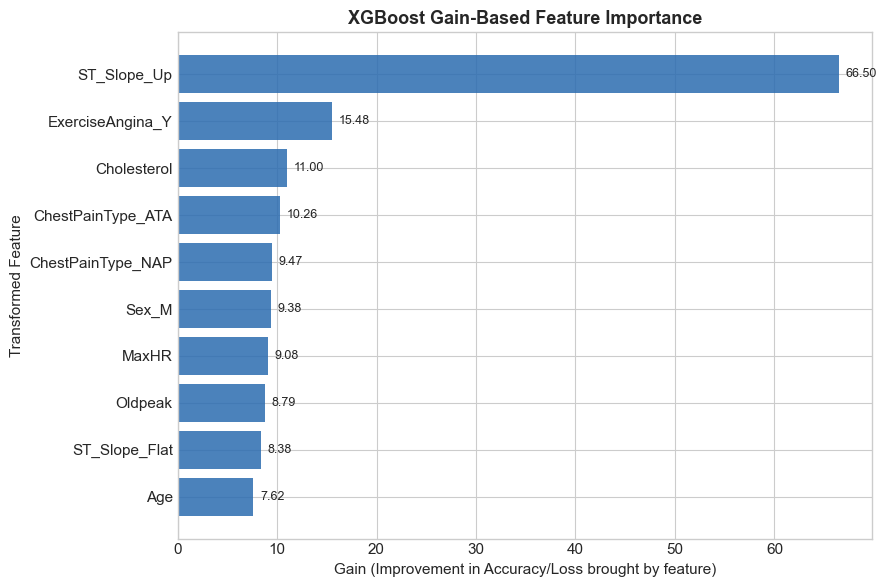

,TransformedFeature,Gain,CleanFeature
0,cat__ST_Slope_Up,66.500580,ST_Slope_Up
1,cat__ExerciseAngina_Y,15.484878,ExerciseAngina_Y
2,num__Cholesterol,11.000919,Cholesterol
3,cat__ChestPainType_ATA,10.263287,ChestPainType_ATA
4,cat__ChestPainType_NAP,9.471039,ChestPainType_NAP
5,cat__Sex_M,9.380387,Sex_M
6,num__MaxHR,9.080795,MaxHR
7,num__Oldpeak,8.794721,Oldpeak
8,cat__ST_Slope_Flat,8.378087,ST_Slope_Flat
9,num__Age,7.619402,Age


In [15]:
# Extract gain feature importance
preprocessor_fitted = best_xgb_pipe.named_steps['preprocessor']
xgb_clf = best_xgb_pipe.named_steps['classifier']

feature_names = list(preprocessor_fitted.get_feature_names_out())
booster = xgb_clf.get_booster()
score_dict = booster.get_score(importance_type='gain')

importances = []
for i, name in enumerate(feature_names):
    gain_val = (
        score_dict.get(name) or
        score_dict.get(f'f{i}') or
        score_dict.get(str(i)) or
        0.0
    )
    importances.append(float(gain_val))

df_imp = pd.DataFrame({
    'TransformedFeature': feature_names,
    'Gain': importances
})

df_imp['CleanFeature'] = (
    df_imp['TransformedFeature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)
df_imp = df_imp.sort_values(by='Gain', ascending=False).reset_index(drop=True)

# Plot top features
plt.figure(figsize=(9, 6))
df_top = df_imp.head(10).sort_values(by='Gain', ascending=True)
bars = plt.barh(df_top['CleanFeature'], df_top['Gain'], color='#2b6cb0', alpha=0.85)
plt.title('XGBoost Gain-Based Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Gain (Improvement in Accuracy/Loss brought by feature)')
plt.ylabel('Transformed Feature')

for bar in bars:
    w = bar.get_width()
    plt.text(w + (0.01 * df_top['Gain'].max()), bar.get_y() + bar.get_height()/2, 
             f"{w:.2f}", va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

display(df_imp.head(10))

---
## 7. 💾 Artifact Serialization for Production Inference

We serialize the unified `ImbPipeline` to `models/xgboost_pipeline.pkl`. At inference time, `imblearn.pipeline.Pipeline` executes only preprocessing and XGBoost prediction, cleanly bypassing SMOTE.

In [16]:
# Save serialized pipeline
os.makedirs(os.path.join('..', 'models'), exist_ok=True)
model_out_path = os.path.join('..', 'models', 'xgboost_pipeline.pkl')
if not os.path.exists(os.path.dirname(model_out_path)):
    model_out_path = 'models/xgboost_pipeline.pkl'

joblib.dump(best_xgb_pipe, model_out_path)
print(f"✓ Unified pipeline artifact saved to: '{model_out_path}'")

# Round-trip verification test
loaded_pipe = joblib.load(model_out_path)
sample_input = pd.DataFrame([{
    'Age': 54, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 140,
    'Cholesterol': 289, 'FastingBS': 0, 'RestingECG': 'Normal',
    'MaxHR': 150, 'ExerciseAngina': 'N', 'Oldpeak': 1.5, 'ST_Slope': 'Flat'
}])

pred = loaded_pipe.predict(sample_input)[0]
prob = loaded_pipe.predict_proba(sample_input)[0][1]

print(f"Sample Inference Test:")
print(f"  Predicted Class: {pred} ({'Higher likelihood' if pred==1 else 'Lower likelihood'})")
print(f"  Model-Estimated Probability: {prob*100:.1f}%")

✓ Unified pipeline artifact saved to: '..\models\xgboost_pipeline.pkl'
Sample Inference Test:
  Predicted Class: 1 (Higher likelihood)
  Model-Estimated Probability: 72.7%
